# End-to-End Fine-tuning: PhoBERT + TF-IDF Hybrid (Positional Encoding + SiLU + Residual)

## Key Optimizations:
1. **No SMOTE/oversampling** - Only uses class-weighted CrossEntropyLoss for class imbalance
2. **Macro-F1 selection** - Uses macro-F1 for model selection (not weighted-F1)
3. **Gradual unfreezing** - PhoBERT layers are gradually unfrozen
4. **Positional encoding** - Adds sinusoidal positional encoding on PhoBERT token embeddings before pooling
5. **SiLU activations** - Uses `nn.SiLU` in projection, residual, and classifier layers
6. **Residual fusion head** - Adds a residual block after hybrid feature fusion
7. **Better fusion** - LayerNorm after concatenation before classification
8. **LSA compression** - Applies `TruncatedSVD` to compress 5000-dim TF-IDF into dense semantic vectors before fusion
9. **Per-class metrics tracking** - Monitors Neutral class F1 during training


## 1. Setup và Import Libraries

In [1]:
import os, sys, json, time, random, copy
from pathlib import Path
from datetime import datetime
from collections import Counter

IN_COLAB = False
try:
    from google.colab import drive  # type: ignore
    IN_COLAB = True
except ImportError:
    drive = None

if IN_COLAB:
    drive.mount('/content/drive')

def find_project_root():
    if IN_COLAB:
        root = Path('/content/drive/MyDrive/Student-Feedback-Sentiment-Analysis')
        if root.exists():
            return root
        raise FileNotFoundError(root)
    cwd = Path.cwd().resolve()
    for candidate in [cwd] + list(cwd.parents):
        if (candidate / 'src').exists() and (candidate / 'data').exists() and (candidate / 'results').exists():
            return candidate
    raise FileNotFoundError('Project root not found')

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
print(f'Project root: {PROJECT_ROOT}')

Mounted at /content/drive
Project root: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis


In [2]:
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from IPython.display import display
from tqdm.auto import tqdm
from src.data_utils import load_data, preprocess_vietnamese

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Configuration

In [3]:
class Config:
    BASE_DIR = str(PROJECT_ROOT)
    DATA_DIR = os.path.join(BASE_DIR, 'data', 'processed')
    MODEL_TYPE = 'PhoBERT_TFIDF_E2E_PosEnc_SiLU_Residual'
    EXPERIMENT_TYPE = 'improvements'
    TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M%S')
    RESULTS_DIR = os.path.join(BASE_DIR, 'results', MODEL_TYPE, EXPERIMENT_TYPE, TIMESTAMP)
    MODELS_DIR = os.path.join(RESULTS_DIR, 'models')
    SUMMARIES_DIR = os.path.join(RESULTS_DIR, 'summaries')
    VISUALIZATIONS_DIR = os.path.join(RESULTS_DIR, 'visualizations')
    ARTIFACTS_DIR = os.path.join(RESULTS_DIR, 'artifacts')

    MODEL_NAME = 'vinai/phobert-base'
    LABEL_MAP = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
    NUM_CLASSES = 3
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    MAX_LENGTH = 256
    BATCH_SIZE = 16
    EPOCHS = 10
    EARLY_STOP_PATIENCE = 3
    WARMUP_RATIO = 0.1
    GRADIENT_CLIP = 1.0
    WEIGHT_DECAY = 0.01
    DROPOUT = 0.3

    # Gradual unfreezing schedule
    PHOBERT_LR_FROZEN = 0.0
    PHOBERT_LR_PARTIAL = 1e-5
    PHOBERT_LR_FULL = 2e-5
    HEAD_LR = 5e-5

    # Unfreezing epochs
    FREEZE_EPOCHS = 1
    PARTIAL_UNFREEZE_EPOCH = 2
    FULL_UNFREEZE_EPOCH = 4
    PARTIAL_UNFREEZE_LAST_N = 4  # Last N layers to unfreeze in partial stage

    # TF-IDF + LSA config
    TFIDF_MAX_FEATURES = 5000
    TFIDF_NGRAM_RANGE = (1, 2)
    TFIDF_MIN_DF = 3
    TFIDF_MAX_DF = 0.90
    TFIDF_SUBLINEAR_TF = True
    TFIDF_LSA_COMPONENTS = 512
    TFIDF_LSA_N_ITER = 10
    TFIDF_LSA_RANDOM_STATE = 42

    TFIDF_PROJ_DIM = 256
    CLASSIFIER_HIDDEN_DIM = 256

    # Selection metric - CRITICAL: use macro-F1
    SELECTION_METRIC = 'f1_macro'

    # Class imbalance handling - ONLY class-weighted loss, NO sampling
    USE_CLASS_WEIGHTS = True  # Use class weights in loss function only

config = Config()
for path in [config.RESULTS_DIR, config.MODELS_DIR, config.SUMMARIES_DIR, config.VISUALIZATIONS_DIR, config.ARTIFACTS_DIR]:
    os.makedirs(path, exist_ok=True)

print('='*60)
print('OPTIMIZED CONFIGURATION (Residual Head, No Oversampling)')
print('='*60)
print(f'Model: {config.MODEL_NAME}')
print(f'TF-IDF Features (sparse): {config.TFIDF_MAX_FEATURES}')
print(f'LSA Components (dense): {config.TFIDF_LSA_COMPONENTS}')
print('Positional Encoding: enabled')
print('Residual Head: enabled')
print(f'Freeze Epochs: {config.FREEZE_EPOCHS}')
print('Activation: SiLU')
print(f'Batch Size: {config.BATCH_SIZE}')
print(f'Epochs: {config.EPOCHS}')
print(f'Selection Metric: {config.SELECTION_METRIC}')
print(f'Class Imbalance Handling: Class-weighted loss only (NO oversampling/sampling)')
print(f'Gradual Unfreezing: freeze<{config.PARTIAL_UNFREEZE_EPOCH}, partial@{config.PARTIAL_UNFREEZE_EPOCH}-{config.FULL_UNFREEZE_EPOCH-1}, full@{config.FULL_UNFREEZE_EPOCH}+')
print(f'Device: {config.DEVICE}')
print(f'Results Dir: {config.RESULTS_DIR}')


OPTIMIZED CONFIGURATION (Residual Head, No Oversampling)
Model: vinai/phobert-base
TF-IDF Features (sparse): 5000
LSA Components (dense): 512
Positional Encoding: enabled
Residual Head: enabled
Freeze Epochs: 1
Activation: SiLU
Batch Size: 16
Epochs: 10
Selection Metric: f1_macro
Class Imbalance Handling: Class-weighted loss only (NO oversampling/sampling)
Gradual Unfreezing: freeze<2, partial@2-3, full@4+
Device: cuda
Results Dir: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_TFIDF_E2E_PosEnc_SiLU_Residual/improvements/20260320_105430


## 3. Load Data

In [4]:
train_texts, train_labels = load_data(config.DATA_DIR, 'train')
val_texts, val_labels = load_data(config.DATA_DIR, 'validation')
test_texts, test_labels = load_data(config.DATA_DIR, 'test')

print('Label distribution:')
for split_name, labels in [('Train', train_labels), ('Validation', val_labels), ('Test', test_labels)]:
    counter = Counter(labels)
    print(f'{split_name}: total={len(labels)}')
    for idx, name in config.LABEL_MAP.items():
        count = counter.get(idx, 0)
        print(f'  {name}: {count} ({count/len(labels)*100:.1f}%)')

Label distribution:
Train: total=11426
  Negative: 5325 (46.6%)
  Neutral: 458 (4.0%)
  Positive: 5643 (49.4%)
Validation: total=1583
  Negative: 705 (44.5%)
  Neutral: 73 (4.6%)
  Positive: 805 (50.9%)
Test: total=3166
  Negative: 1409 (44.5%)
  Neutral: 167 (5.3%)
  Positive: 1590 (50.2%)


## 4. TF-IDF + LSA Feature Extraction

In [5]:
train_texts_processed = [preprocess_vietnamese(text) for text in train_texts]
val_texts_processed = [preprocess_vietnamese(text) for text in val_texts]
test_texts_processed = [preprocess_vietnamese(text) for text in test_texts]

tfidf_vectorizer = TfidfVectorizer(
    max_features=config.TFIDF_MAX_FEATURES,
    ngram_range=config.TFIDF_NGRAM_RANGE,
    min_df=config.TFIDF_MIN_DF,
    max_df=config.TFIDF_MAX_DF,
    sublinear_tf=config.TFIDF_SUBLINEAR_TF
)

train_tfidf_sparse = tfidf_vectorizer.fit_transform(train_texts_processed).astype(np.float32)
val_tfidf_sparse = tfidf_vectorizer.transform(val_texts_processed).astype(np.float32)
test_tfidf_sparse = tfidf_vectorizer.transform(test_texts_processed).astype(np.float32)

max_lsa_dim = max(1, min(train_tfidf_sparse.shape[0] - 1, train_tfidf_sparse.shape[1] - 1))
effective_lsa_dim = min(config.TFIDF_LSA_COMPONENTS, max_lsa_dim)
if effective_lsa_dim != config.TFIDF_LSA_COMPONENTS:
    print(
        f'Requested LSA dim={config.TFIDF_LSA_COMPONENTS} but TF-IDF matrix allows at most {max_lsa_dim}; '
        f'using {effective_lsa_dim} components instead.'
    )

tfidf_lsa = TruncatedSVD(
    n_components=effective_lsa_dim,
    n_iter=config.TFIDF_LSA_N_ITER,
    random_state=config.TFIDF_LSA_RANDOM_STATE
)

train_tfidf = tfidf_lsa.fit_transform(train_tfidf_sparse).astype(np.float32)
val_tfidf = tfidf_lsa.transform(val_tfidf_sparse).astype(np.float32)
test_tfidf = tfidf_lsa.transform(test_tfidf_sparse).astype(np.float32)

tfidf_scaler = StandardScaler()
train_tfidf = tfidf_scaler.fit_transform(train_tfidf).astype(np.float32)
val_tfidf = tfidf_scaler.transform(val_tfidf).astype(np.float32)
test_tfidf = tfidf_scaler.transform(test_tfidf).astype(np.float32)

tfidf_input_dim = train_tfidf.shape[1]
lsa_explained_variance = float(tfidf_lsa.explained_variance_ratio_.sum())

joblib.dump(tfidf_vectorizer, os.path.join(config.ARTIFACTS_DIR, 'tfidf_vectorizer.pkl'))
joblib.dump(tfidf_lsa, os.path.join(config.ARTIFACTS_DIR, 'tfidf_lsa.pkl'))
joblib.dump(tfidf_scaler, os.path.join(config.ARTIFACTS_DIR, 'tfidf_lsa_scaler.pkl'))
print(f'TF-IDF sparse shapes: Train={train_tfidf_sparse.shape}, Val={val_tfidf_sparse.shape}, Test={test_tfidf_sparse.shape}')
print(f'LSA dense shapes: Train={train_tfidf.shape}, Val={val_tfidf.shape}, Test={test_tfidf.shape}')
print(f'LSA explained variance ratio sum: {lsa_explained_variance:.4f}')

TF-IDF sparse shapes: Train=(11426, 5000), Val=(1583, 5000), Test=(3166, 5000)
LSA dense shapes: Train=(11426, 512), Val=(1583, 512), Test=(3166, 512)
LSA explained variance ratio sum: 0.6393


## 5. Dataset & Model Definition

In [6]:
class HybridDataset(Dataset):
    """Dataset for hybrid PhoBERT + TF-IDF features"""
    def __init__(self, texts, tfidf_features, labels, tokenizer, max_length):
        self.texts = texts
        self.tfidf_features = tfidf_features
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        tfidf = np.asarray(self.tfidf_features[idx], dtype=np.float32).ravel()

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'tfidf': torch.tensor(tfidf, dtype=torch.float),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [7]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len, dropout=0.1):
        super().__init__()
        position = torch.arange(max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float)
            * (-torch.log(torch.tensor(10000.0)) / d_model)
        )
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term[:pe[:, 1::2].shape[1]])
        self.register_buffer('pe', pe.unsqueeze(0))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        seq_len = x.size(1)
        return self.dropout(x + self.pe[:, :seq_len, :].to(dtype=x.dtype))


class PhoBERTTFIDFHybridResidual(nn.Module):
    """Hybrid PhoBERT + TF-IDF model with positional encoding and residual fusion head."""
    def __init__(self, model_name, tfidf_dim, num_classes, dropout=0.3):
        super().__init__()

        self.phobert = AutoModel.from_pretrained(model_name)
        phobert_dim = self.phobert.config.hidden_size
        max_pos = max(getattr(self.phobert.config, 'max_position_embeddings', config.MAX_LENGTH), config.MAX_LENGTH)
        self.positional_encoding = PositionalEncoding(phobert_dim, max_pos, dropout)

        self.tfidf_proj = nn.Sequential(
            nn.Linear(tfidf_dim, config.TFIDF_PROJ_DIM),
            nn.LayerNorm(config.TFIDF_PROJ_DIM),
            nn.SiLU(),
            nn.Dropout(dropout)
        )

        combined_dim = phobert_dim + config.TFIDF_PROJ_DIM
        self.fusion_norm = nn.LayerNorm(combined_dim)
        self.classifier_input = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(combined_dim, config.CLASSIFIER_HIDDEN_DIM),
            nn.LayerNorm(config.CLASSIFIER_HIDDEN_DIM),
            nn.SiLU()
        )
        self.residual_block = nn.Sequential(
            nn.LayerNorm(config.CLASSIFIER_HIDDEN_DIM),
            nn.Dropout(dropout),
            nn.Linear(config.CLASSIFIER_HIDDEN_DIM, config.CLASSIFIER_HIDDEN_DIM),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(config.CLASSIFIER_HIDDEN_DIM, config.CLASSIFIER_HIDDEN_DIM)
        )
        self.classifier = nn.Sequential(
            nn.LayerNorm(config.CLASSIFIER_HIDDEN_DIM),
            nn.Dropout(dropout),
            nn.Linear(config.CLASSIFIER_HIDDEN_DIM, num_classes)
        )

    def forward(self, input_ids, attention_mask, tfidf_features):
        outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        token_embeddings = self.positional_encoding(outputs.last_hidden_state)
        mask = attention_mask.unsqueeze(-1).type_as(token_embeddings)
        phobert_emb = (token_embeddings * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)

        tfidf_proj = self.tfidf_proj(tfidf_features)
        combined = torch.cat([phobert_emb, tfidf_proj], dim=1)
        combined = self.fusion_norm(combined)

        fused = self.classifier_input(combined)
        fused = fused + self.residual_block(fused)
        logits = self.classifier(fused)
        return logits


def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)
model = PhoBERTTFIDFHybridResidual(
    model_name=config.MODEL_NAME,
    tfidf_dim=tfidf_input_dim,
    num_classes=config.NUM_CLASSES,
    dropout=config.DROPOUT
).to(config.DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'TF-IDF input dim to model: {tfidf_input_dim}')
print(f'Total parameters: {total_params:,}')
print(f'Initial trainable parameters: {count_trainable_params(model):,}')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


TF-IDF input dim to model: 512
Total parameters: 135,528,451
Initial trainable parameters: 135,528,451


## 6. Create DataLoaders (No Sampling)

**Key approach**: No oversampling/sampling techniques. Class imbalance is handled solely through class-weighted CrossEntropyLoss.

In [8]:
# TF-IDF has already been converted to dense LSA vectors
train_tfidf_dense = train_tfidf.astype(np.float32)
val_tfidf_dense = val_tfidf.astype(np.float32)
test_tfidf_dense = test_tfidf.astype(np.float32)

# Create datasets
train_dataset = HybridDataset(train_texts, train_tfidf_dense, train_labels, tokenizer, config.MAX_LENGTH)
val_dataset = HybridDataset(val_texts, val_tfidf_dense, val_labels, tokenizer, config.MAX_LENGTH)
test_dataset = HybridDataset(test_texts, test_tfidf_dense, test_labels, tokenizer, config.MAX_LENGTH)

# Create dataloaders with standard shuffling (no sampling)
train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True  # Standard shuffle, no sampling
)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

print(f'TF-IDF dense feature dim after LSA: {tfidf_input_dim}')
print(f'Train batches: {len(train_loader)}')
print(f'Val batches: {len(val_loader)}')
print(f'Test batches: {len(test_loader)}')
print('\nNo oversampling/sampling applied. Class imbalance handled via class-weighted loss only.')

TF-IDF dense feature dim after LSA: 512
Train batches: 715
Val batches: 99
Test batches: 198

No oversampling/sampling applied. Class imbalance handled via class-weighted loss only.


## 7. Training Setup with Gradual Unfreezing

In [9]:
# Compute class weights for loss function (ONLY mechanism for handling class imbalance)
if config.USE_CLASS_WEIGHTS:
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.array([0, 1, 2]),
        y=np.array(train_labels)
    )
    class_weights = torch.tensor(class_weights, dtype=torch.float).to(config.DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    print(f'Class weights for loss: {class_weights.tolist()}')
else:
    criterion = nn.CrossEntropyLoss()
    print('No class weights used')


def get_training_stage(epoch_number):
    """Determine training stage based on epoch number."""
    if epoch_number <= config.FREEZE_EPOCHS:
        return 'frozen'
    if epoch_number < config.FULL_UNFREEZE_EPOCH:
        return 'partial'
    return 'full'


def set_phobert_trainable_layers(model, stage):
    """Set PhoBERT layers trainable based on training stage."""
    # First freeze all PhoBERT parameters
    for param in model.phobert.parameters():
        param.requires_grad = False

    if stage == 'partial':
        # Unfreeze last N encoder layers
        encoder_layers = model.phobert.encoder.layer
        for layer in encoder_layers[-config.PARTIAL_UNFREEZE_LAST_N:]:
            for param in layer.parameters():
                param.requires_grad = True
    elif stage == 'full':
        # Unfreeze all PhoBERT parameters
        for param in model.phobert.parameters():
            param.requires_grad = True

    # Always keep projection and classifier trainable
    for module in [model.tfidf_proj, model.fusion_norm, model.classifier_input, model.residual_block, model.classifier]:
        for param in module.parameters():
            param.requires_grad = True


def build_optimizer_and_scheduler(model, stage, epoch_number):
    """Build optimizer with discriminative learning rates."""
    phobert_lr = {
        'frozen': config.PHOBERT_LR_FROZEN,
        'partial': config.PHOBERT_LR_PARTIAL,
        'full': config.PHOBERT_LR_FULL
    }[stage]

    optimizer_groups = []

    # PhoBERT parameters (if trainable)
    phobert_params = [p for p in model.phobert.parameters() if p.requires_grad]
    if phobert_params:
        optimizer_groups.append({'params': phobert_params, 'lr': phobert_lr})

    # Head parameters (always trainable with higher LR)
    head_params = [
        p
        for module in [model.tfidf_proj, model.fusion_norm, model.classifier_input, model.residual_block, model.classifier]
        for p in module.parameters()
        if p.requires_grad
    ]
    optimizer_groups.append({'params': head_params, 'lr': config.HEAD_LR})

    optimizer = torch.optim.AdamW(optimizer_groups, weight_decay=config.WEIGHT_DECAY)

    # Calculate remaining steps for scheduler
    remaining_epochs = config.EPOCHS - epoch_number + 1
    total_steps = max(1, remaining_epochs * len(train_loader))
    warmup_steps = int(total_steps * config.WARMUP_RATIO)

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    return optimizer, scheduler, phobert_lr, total_steps, warmup_steps


# Initial setup - freeze PhoBERT
set_phobert_trainable_layers(model, 'frozen')
print(f'Trainable params after freeze: {count_trainable_params(model):,}')


Class weights for loss: [0.7152425646781921, 8.315866470336914, 0.6749364733695984]
Trainable params after freeze: 530,179


## 8. Training Loop

In [10]:
def train_epoch(model, dataloader, criterion, optimizer, scheduler, device):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for batch in tqdm(dataloader, desc='Training', leave=False):
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        tfidf = batch['tfidf'].to(device)
        labels = batch['label'].to(device)

        logits = model(input_ids, attention_mask, tfidf)
        loss = criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), config.GRADIENT_CLIP)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    return avg_loss, accuracy, f1_macro


def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating', leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            tfidf = batch['tfidf'].to(device)
            labels = batch['label'].to(device)

            logits = model(input_ids, attention_mask, tfidf)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    f1_weighted = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    accuracy = accuracy_score(all_labels, all_preds)

    # Per-class metrics
    precision_pc, recall_pc, f1_pc, support_pc = precision_recall_fscore_support(
        all_labels, all_preds, labels=[0, 1, 2], zero_division=0
    )

    return {
        'loss': avg_loss,
        'accuracy': accuracy,
        'precision_macro': precision,
        'recall_macro': recall,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'precision_per_class': precision_pc.tolist(),
        'recall_per_class': recall_pc.tolist(),
        'f1_per_class': f1_pc.tolist(),
        'support_per_class': support_pc.tolist(),
        'confusion_matrix': confusion_matrix(all_labels, all_preds, labels=[0, 1, 2]).tolist(),
        'y_pred': list(map(int, all_preds)),
        'y_true': list(map(int, all_labels)),
    }

In [11]:
# Training loop
history = {
    'epoch': [], 'stage': [],
    'train_loss': [], 'train_acc': [], 'train_f1_macro': [],
    'val_loss': [], 'val_acc': [], 'val_f1_macro': [], 'val_f1_neutral': [],
    'phobert_lr': [], 'trainable_params': []
}

best_val_f1 = -1.0
best_epoch = 0
best_stage = None
best_model_state = None
patience_counter = 0
current_stage = None
optimizer = None
scheduler = None

print('='*70)
print('START TRAINING WITH GRADUAL UNFREEZING (No Oversampling)')
print('='*70)

for epoch in range(1, config.EPOCHS + 1):
    stage = get_training_stage(epoch)

    if stage != current_stage:
        current_stage = stage
        set_phobert_trainable_layers(model, stage)
        optimizer, scheduler, phobert_lr, total_steps, warmup_steps = build_optimizer_and_scheduler(model, stage, epoch)
        print(f'\n[Stage Switch] epoch={epoch} stage={stage} phobert_lr={phobert_lr} trainable_params={count_trainable_params(model):,}')

    print(f'\nEpoch {epoch}/{config.EPOCHS}')

    train_loss, train_acc, train_f1 = train_epoch(model, train_loader, criterion, optimizer, scheduler, config.DEVICE)
    val_metrics = evaluate(model, val_loader, criterion, config.DEVICE)

    history['epoch'].append(epoch)
    history['stage'].append(stage)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1_macro'].append(train_f1)
    history['val_loss'].append(val_metrics['loss'])
    history['val_acc'].append(val_metrics['accuracy'])
    history['val_f1_macro'].append(val_metrics['f1_macro'])
    history['val_f1_neutral'].append(val_metrics['f1_per_class'][1])
    history['phobert_lr'].append(phobert_lr)
    history['trainable_params'].append(count_trainable_params(model))

    print(f'Train  - loss={train_loss:.4f} acc={train_acc:.4f} f1_macro={train_f1:.4f}')
    print(f"Val    - loss={val_metrics['loss']:.4f} acc={val_metrics['accuracy']:.4f} f1_macro={val_metrics['f1_macro']:.4f} f1_neutral={val_metrics['f1_per_class'][1]:.4f}")

    # Model selection based on MACRO F1 (critical fix)
    if val_metrics['f1_macro'] > best_val_f1:
        best_val_f1 = val_metrics['f1_macro']
        best_epoch = epoch
        best_stage = stage
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
        torch.save(best_model_state, os.path.join(config.MODELS_DIR, 'best_model.pt'))
        print(f'  -> New best model saved (val macro F1={best_val_f1:.4f})')
    else:
        patience_counter += 1
        print(f'  -> No improvement, patience={patience_counter}/{config.EARLY_STOP_PATIENCE}')
        if patience_counter >= config.EARLY_STOP_PATIENCE:
            print(f'  -> Early stopping at epoch {epoch}')
            break

assert best_model_state is not None
model.load_state_dict(best_model_state)

# Save training history
history_df = pd.DataFrame(history)
history_df.to_csv(os.path.join(config.SUMMARIES_DIR, 'training_history.csv'), index=False)

print(f'\nBest epoch: {best_epoch}, best stage: {best_stage}, best val macro F1: {best_val_f1:.4f}')

START TRAINING WITH GRADUAL UNFREEZING (No Oversampling)

[Stage Switch] epoch=1 stage=frozen phobert_lr=0.0 trainable_params=530,179

Epoch 1/10


Training:   0%|          | 0/715 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/99 [00:00<?, ?it/s]

Train  - loss=1.0570 acc=0.5824 f1_macro=0.4451
Val    - loss=0.8810 acc=0.8124 f1_macro=0.6465 f1_neutral=0.2800
  -> New best model saved (val macro F1=0.6465)

[Stage Switch] epoch=2 stage=partial phobert_lr=1e-05 trainable_params=28,881,667

Epoch 2/10


Training:   0%|          | 0/715 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/99 [00:00<?, ?it/s]

Train  - loss=0.0895 acc=0.9865 f1_macro=0.9711
Val    - loss=1.0450 acc=0.9387 f1_macro=0.8421 f1_neutral=0.6197
  -> No improvement, patience=1/3

Epoch 10/10


Training:   0%|          | 0/715 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/99 [00:00<?, ?it/s]

Train  - loss=0.0723 acc=0.9893 f1_macro=0.9796
Val    - loss=1.1249 acc=0.9400 f1_macro=0.8406 f1_neutral=0.6131
  -> No improvement, patience=2/3

Best epoch: 8, best stage: full, best val macro F1: 0.8541


## 9. Evaluation on Test Set

In [12]:
val_results = evaluate(model, val_loader, criterion, config.DEVICE)
test_results = evaluate(model, test_loader, criterion, config.DEVICE)

print('Validation Classification Report:')
print(classification_report(val_results['y_true'], val_results['y_pred'], target_names=list(config.LABEL_MAP.values()), zero_division=0))

print('\nTest Classification Report:')
print(classification_report(test_results['y_true'], test_results['y_pred'], target_names=list(config.LABEL_MAP.values()), zero_division=0))

Evaluating:   0%|          | 0/99 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/198 [00:00<?, ?it/s]

Validation Classification Report:
              precision    recall  f1-score   support

    Negative       0.95      0.95      0.95       705
     Neutral       0.67      0.63      0.65        73
    Positive       0.96      0.97      0.96       805

    accuracy                           0.94      1583
   macro avg       0.86      0.85      0.85      1583
weighted avg       0.94      0.94      0.94      1583


Test Classification Report:
              precision    recall  f1-score   support

    Negative       0.95      0.94      0.95      1409
     Neutral       0.65      0.56      0.60       167
    Positive       0.94      0.96      0.95      1590

    accuracy                           0.93      3166
   macro avg       0.85      0.82      0.83      3166
weighted avg       0.93      0.93      0.93      3166



## 10. Save Results

In [13]:
# Summary dataframe
summary_df = pd.DataFrame([
    {
        'Split': 'Validation', 'Best_Epoch': best_epoch, 'Best_Stage': best_stage,
        'Accuracy': val_results['accuracy'], 'F1_Macro': val_results['f1_macro'],
        'F1_Weighted': val_results['f1_weighted'],
        'F1_Negative': val_results['f1_per_class'][0],
        'F1_Neutral': val_results['f1_per_class'][1],
        'F1_Positive': val_results['f1_per_class'][2]
    },
    {
        'Split': 'Test', 'Best_Epoch': best_epoch, 'Best_Stage': best_stage,
        'Accuracy': test_results['accuracy'], 'F1_Macro': test_results['f1_macro'],
        'F1_Weighted': test_results['f1_weighted'],
        'F1_Negative': test_results['f1_per_class'][0],
        'F1_Neutral': test_results['f1_per_class'][1],
        'F1_Positive': test_results['f1_per_class'][2]
    },
])
display(summary_df)
summary_df.to_csv(os.path.join(config.SUMMARIES_DIR, 'summary.csv'), index=False)

experiment_summary = {
    'model_type': config.MODEL_TYPE,
    'experiment_type': config.EXPERIMENT_TYPE,
    'timestamp': config.TIMESTAMP,
    'epochs_configured': config.EPOCHS,
    'best_epoch': best_epoch,
    'best_stage': best_stage,
    'selection_metric': config.SELECTION_METRIC,
    'best_val_f1_macro': best_val_f1,
    'class_imbalance_handling': 'class_weighted_loss_only',
    'tfidf_lsa': {
        'max_features': config.TFIDF_MAX_FEATURES,
        'lsa_components_requested': config.TFIDF_LSA_COMPONENTS,
        'lsa_components_used': int(tfidf_input_dim),
        'lsa_explained_variance_ratio_sum': lsa_explained_variance,
        'projection_dim': config.TFIDF_PROJ_DIM
    },
    'unfreezing_schedule': {
        'freeze_epochs': list(range(1, config.FREEZE_EPOCHS + 1)),
        'partial_unfreeze_start_epoch': config.PARTIAL_UNFREEZE_EPOCH,
        'partial_unfreeze_last_n_layers': config.PARTIAL_UNFREEZE_LAST_N,
        'full_unfreeze_start_epoch': config.FULL_UNFREEZE_EPOCH
    },
    'validation': val_results,
    'test': test_results,
}
with open(os.path.join(config.SUMMARIES_DIR, 'experiment_summary.json'), 'w', encoding='utf-8') as f:
    json.dump(experiment_summary, f, ensure_ascii=False, indent=2)

# Training results text
with open(os.path.join(config.SUMMARIES_DIR, 'training_results.txt'), 'w', encoding='utf-8') as f:
    f.write('='*60 + '\n')
    f.write('TRAINING RESULTS - PhoBERT + TF-IDF End-to-End (Positional Encoding + SiLU, No Oversampling)\n')
    f.write('='*60 + '\n')
    f.write(f'Date: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}\n')
    f.write(f'Results Dir: {config.RESULTS_DIR}\n')
    f.write(f'Best Epoch: {best_epoch}\n')
    f.write(f'Best Stage: {best_stage}\n')
    f.write(f'TF-IDF Sparse Dim: {config.TFIDF_MAX_FEATURES}\n')
    f.write(f'TF-IDF LSA Dim: {tfidf_input_dim}\n')
    f.write(f'LSA Explained Variance Ratio Sum: {lsa_explained_variance:.4f}\n')
    f.write(f'Class Imbalance Handling: Class-weighted loss only (NO oversampling)\n')
    f.write(f'Best Val Macro F1: {best_val_f1:.4f}\n')
    f.write(f'Test Accuracy: {test_results["accuracy"]:.4f}\n')
    f.write(f'Test F1 Macro: {test_results["f1_macro"]:.4f}\n')
    f.write(f'Test F1 Weighted: {test_results["f1_weighted"]:.4f}\n')
    f.write(f'Test F1 Neutral: {test_results["f1_per_class"][1]:.4f}\n')

print(f'Saved outputs to: {config.RESULTS_DIR}')

,Split,Best_Epoch,Best_Stage,Accuracy,F1_Macro,F1_Weighted,F1_Negative,F1_Neutral,F1_Positive
0,Validation,8,full,0.943778,0.854112,0.943359,0.950890,0.647887,0.963558
1,Test,8,full,0.931143,0.833464,0.929889,0.946918,0.604502,0.948973


Saved outputs to: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_TFIDF_E2E_PosEnc_SiLU_Residual/improvements/20260320_105430


## 11. Visualization

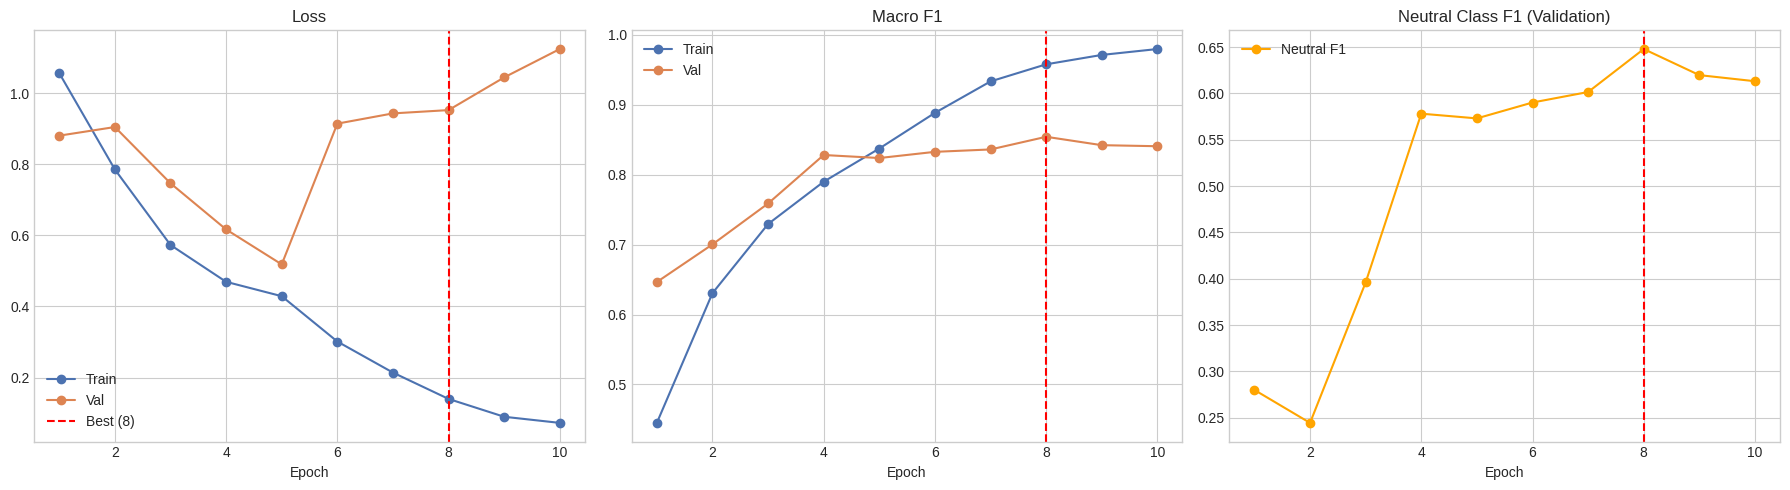

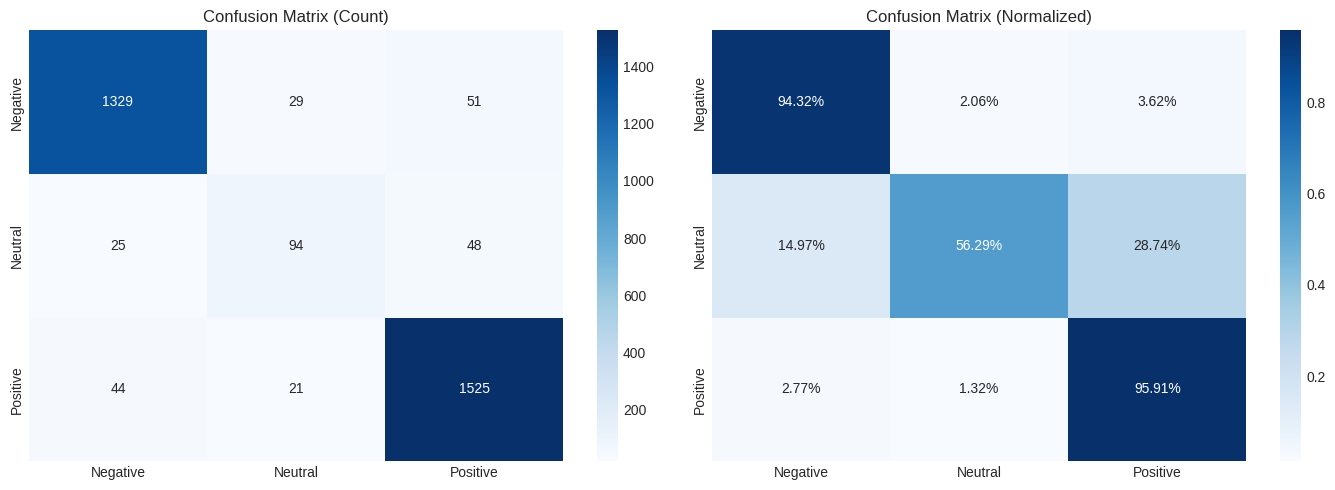

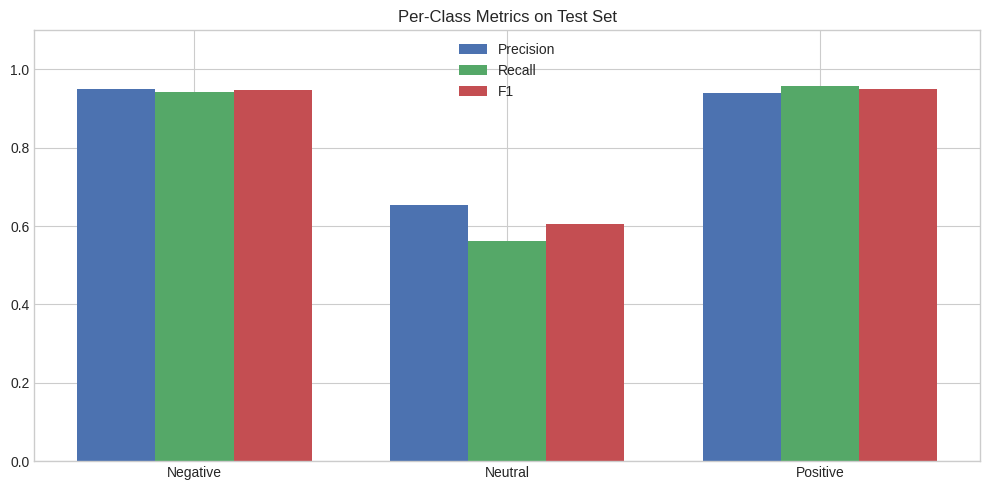

In [14]:
# Training history
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history_df['epoch'], history_df['train_loss'], marker='o', label='Train')
axes[0].plot(history_df['epoch'], history_df['val_loss'], marker='o', label='Val')
axes[0].axvline(best_epoch, color='red', linestyle='--', label=f'Best ({best_epoch})')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_df['epoch'], history_df['train_f1_macro'], marker='o', label='Train')
axes[1].plot(history_df['epoch'], history_df['val_f1_macro'], marker='o', label='Val')
axes[1].axvline(best_epoch, color='red', linestyle='--')
axes[1].set_title('Macro F1')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history_df['epoch'], history_df['val_f1_neutral'], marker='o', color='orange', label='Neutral F1')
axes[2].axvline(best_epoch, color='red', linestyle='--')
axes[2].set_title('Neutral Class F1 (Validation)')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'training_history.png'), dpi=150, bbox_inches='tight')
plt.show()

# Confusion matrix
cm = np.array(test_results['confusion_matrix'])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(config.LABEL_MAP.values()),
            yticklabels=list(config.LABEL_MAP.values()), ax=axes[0])
axes[0].set_title('Confusion Matrix (Count)')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=list(config.LABEL_MAP.values()),
            yticklabels=list(config.LABEL_MAP.values()), ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)')
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

# Per-class metrics
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(config.LABEL_MAP))
width = 0.25
ax.bar(x - width, test_results['precision_per_class'], width, label='Precision', color='#4C72B0')
ax.bar(x, test_results['recall_per_class'], width, label='Recall', color='#55A868')
ax.bar(x + width, test_results['f1_per_class'], width, label='F1', color='#C44E52')
ax.set_xticks(x)
ax.set_xticklabels(list(config.LABEL_MAP.values()))
ax.set_ylim(0, 1.1)
ax.set_title('Per-Class Metrics on Test Set')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'per_class_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()

## 12. Error Analysis for Neutral Class

In [15]:
# Find misclassified Neutral samples
neutral_indices = [i for i, label in enumerate(test_results['y_true']) if label == 1]
misclassified_neutral = [
    (i, test_results['y_pred'][i], test_texts[i])
    for i in neutral_indices
    if test_results['y_pred'][i] != 1
]

print(f'Total Neutral samples: {len(neutral_indices)}')
print(f'Misclassified Neutral: {len(misclassified_neutral)}')
print(f'Neutral accuracy: {1 - len(misclassified_neutral)/len(neutral_indices):.2%}')

print('\n--- Sample Misclassified Neutral Feedback ---')
for idx, pred, text in misclassified_neutral[:10]:
    pred_label = config.LABEL_MAP[pred]
    print(f'  Predicted: {pred_label} | Text: "{text[:80]}..."' if len(text) > 80 else f'  Predicted: {pred_label} | Text: "{text}"')

# Count which classes Neutral is confused with
from collections import Counter
confusion_targets = Counter([pred for _, pred, _ in misclassified_neutral])
print(f'\nNeutral confusion targets:')
for cls, count in sorted(confusion_targets.items()):
    print(f'  {config.LABEL_MAP[cls]}: {count}')

Total Neutral samples: 167
Misclassified Neutral: 73
Neutral accuracy: 56.29%

--- Sample Misclassified Neutral Feedback ---
  Predicted: Positive | Text: "cách mà cô tiếp cận với sinh viên"
  Predicted: Positive | Text: "môn học này giúp chúng em hiểu ra những vấn đề cơ bản"
  Predicted: Negative | Text: "như vậy tụi em sẽ định hướng tốt hơn và tập trung vào những thứ cần thiết"
  Predicted: Positive | Text: "ví dụ phù hợp với nội dung kiến thức hướng dẫn chị tiết"
  Predicted: Positive | Text: "kỹ những chương cuối"
  Predicted: Positive | Text: "cô cho em 10 điểm thực hành colonlove"
  Predicted: Positive | Text: "có kết hợp với bài tập ví dụ"
  Predicted: Positive | Text: "bài tập đầy đủ"
  Predicted: Positive | Text: "có cung cấp tài liệu cho sinh viên"
  Predicted: Positive | Text: "ngoài ra còn nhiều kiến thức ngoài"

Neutral confusion targets:
  Negative: 25
  Positive: 48


## 13. Final Summary

In [16]:
print('='*70)
print('MODEL + POSITIONAL ENCODING + SILU + RESIDUAL - FINAL SUMMARY')
print('='*70)

print('\nKey Optimizations Applied:')
print('  1. Class-weighted CrossEntropyLoss only (NO oversampling/sampling)')
print('  2. Macro-F1 for model selection (not weighted-F1)')
print('  3. Gradual unfreezing: frozen -> partial -> full')
print('  4. Positional encoding on PhoBERT token embeddings before pooling')
print('  5. SiLU activations in projection, residual, and classifier layers')
print('  6. Residual block after fusion projection')
print('  7. LayerNorm after concatenation for better fusion')
print(f'  8. LSA compression: {config.TFIDF_MAX_FEATURES} -> {tfidf_input_dim} dense dimensions')
print(f'     Explained variance ratio sum: {lsa_explained_variance:.4f}')

print(f'\nBest epoch: {best_epoch}')
print(f'Best stage: {best_stage}')
print(f'Best val macro F1: {best_val_f1:.4f}')

print(f'\nTest Results:')
print(f'  Accuracy: {test_results["accuracy"]:.4f}')
print(f'  F1 Macro: {test_results["f1_macro"]:.4f}')
print(f'  F1 Weighted: {test_results["f1_weighted"]:.4f}')

print('\nPer-Class F1:')
for i, name in config.LABEL_MAP.items():
    print(f'  {name}: {test_results["f1_per_class"][i]:.4f}')

print('\n' + '='*70)


MODEL + POSITIONAL ENCODING + SILU + RESIDUAL - FINAL SUMMARY

Key Optimizations Applied:
  1. Class-weighted CrossEntropyLoss only (NO oversampling/sampling)
  2. Macro-F1 for model selection (not weighted-F1)
  3. Gradual unfreezing: frozen -> partial -> full
  4. Positional encoding on PhoBERT token embeddings before pooling
  5. SiLU activations in projection, residual, and classifier layers
  6. Residual block after fusion projection
  7. LayerNorm after concatenation for better fusion
  8. LSA compression: 5000 -> 512 dense dimensions
     Explained variance ratio sum: 0.6393

Best epoch: 8
Best stage: full
Best val macro F1: 0.8541

Test Results:
  Accuracy: 0.9311
  F1 Macro: 0.8335
  F1 Weighted: 0.9299

Per-Class F1:
  Negative: 0.9469
  Neutral: 0.6045
  Positive: 0.9490

